In [1]:
from skimage.feature import peak_local_max

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.graph_objects as go
import plotly.express as px

import numpy as np
import pandas as pd
import trackpy as tp


import csv
import importlib
import sys
import os
cur=os.getcwd()
paths = [cur := os.path.dirname(cur) for _ in range(3)]
sys.path.insert(0, paths[0])
from Helpers import loadData
importlib.reload(sys.modules['Helpers.loadData'])
importlib.reload(sys.modules['Helpers'])

importlib.reload(sys.modules['Helpers'])

<module 'Helpers' from 'd:\\temp1\\Granular-Compression\\Identification\\Helpers\\__init__.py'>

In [2]:
procData = rf'{paths[1]}\DataProcessed\sphereScans'
files = os.listdir(procData)

posFiles = [f for f in files if f.endswith('.npy')]

In [9]:
divisNum = 4
cycleNum = max([int(scan.split('s')[0].replace('Cycle','')) for scan in posFiles])

rows = []
for i in range(cycleNum):
    for j in range(divisNum):
        name = f'Cycle{i+1}s{j+1}.npy'
        peak = np.load(rf'{procData}\{name}')

        for (x,y,z) in peak:
            rows.append({'frame': i*divisNum+j+1, 'x':x, 'y':y, 'z':z})

df = pd.DataFrame(rows)

In [10]:
linked = tp.link(df, search_range=30, memory=5, pos_columns=['x','y','z'])
linked = tp.filter_stubs(linked, threshold=100)
linked = linked.reset_index(drop=True)

print(linked['particle'].nunique(), "trajectories found")

Frame 800: 54 trajectories present.
99 trajectories found


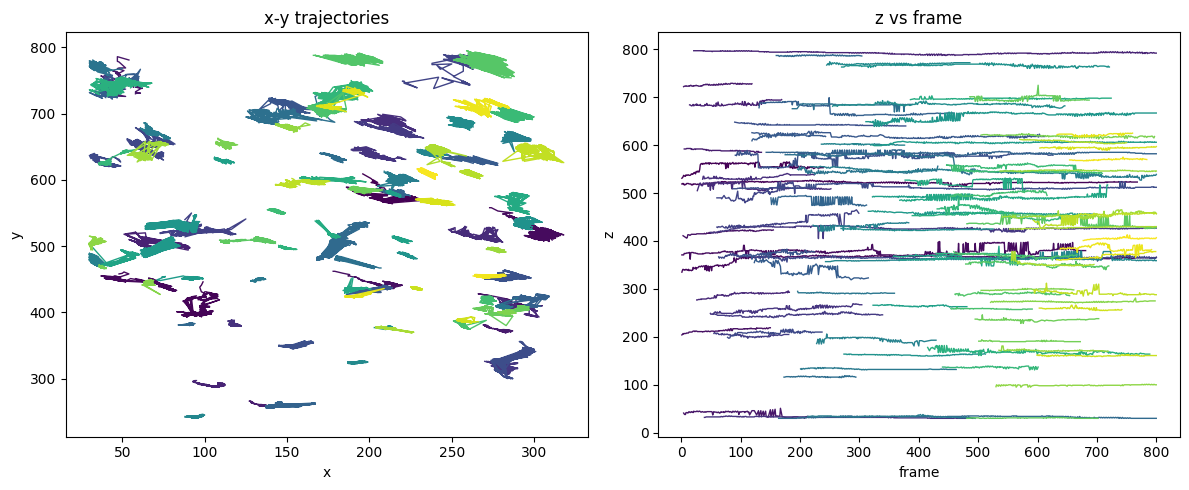

In [11]:
n_traj = linked['particle'].nunique()
colors = cm.viridis([i / n_traj for i in range(n_traj)])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i, (pid, traj) in enumerate(linked.groupby('particle')):
    traj = traj.sort_values('frame')
    ax[0].plot(traj['x'], traj['y'], color=colors[i], lw=1)
    ax[1].plot(traj['frame'], traj['z'], color=colors[i], lw=1)

ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].set_title('x-y trajectories')
ax[1].set_xlabel('frame'); ax[1].set_ylabel('z'); ax[1].set_title('z vs frame')

plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()

particle_ids = linked['particle'].unique()
colors = px.colors.sample_colorscale('viridis', [i/len(particle_ids) for i in range(len(particle_ids))])

for i, pid in enumerate(particle_ids):
    traj = linked[linked['particle'] == pid].sort_values('frame')
    fig.add_trace(go.Scatter3d(
        x=traj['x'], y=traj['y'], z=traj['z'],
        mode='lines',
        line=dict(color=colors[i], width=3),
        name=f'particle {pid}',
        hovertemplate='frame=%{customdata}<br>x=%{x}<br>y=%{y}<br>z=%{z}',
        customdata=traj['frame']
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    ),
    title='3D particle trajectories',
    width=900,
    height=800,
    showlegend=False  # flip to True if you want a clickable legend, gets noisy with many tracks
)

fig.show()